In [4]:
import numpy as np
import pandas as pd
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('patient_churn_dataset.csv')
df.head()

,PatientID,Age,Gender,State,Tenure_Months,Specialty,Insurance_Type,Visits_Last_Year,Missed_Appointments,Days_Since_Last_Visit,...,Overall_Satisfaction,Wait_Time_Satisfaction,Staff_Satisfaction,Provider_Rating,Avg_Out_Of_Pocket_Cost,Billing_Issues,Portal_Usage,Referrals_Made,Distance_To_Facility_Miles,Churned
0,C20000,41,Female,PA,62,Pediatrics,Medicaid,1,0,564,...,3.5,4.9,3.8,4.2,306,0,0,3,21.4,1
1,C20001,43,Female,GA,44,Internal Medicine,Self-Pay,7,4,254,...,2.6,3.1,4.7,4.3,1851,0,0,0,47.6,1
2,C20002,21,Male,MI,120,Internal Medicine,Medicaid,15,5,89,...,1.6,4.4,2.1,4.7,391,0,0,2,7.1,0
3,C20003,65,Male,FL,118,General Practice,Private,10,3,135,...,2.6,4.3,4.3,4.9,808,0,0,0,11.6,1
4,C20004,18,Female,CA,70,Cardiology,Medicaid,5,4,696,...,2.2,4.0,4.1,4.4,866,0,0,0,10.3,1


In [6]:
df.columns

Index(['PatientID', 'Age', 'Gender', 'State', 'Tenure_Months', 'Specialty',
       'Insurance_Type', 'Visits_Last_Year', 'Missed_Appointments',
       'Days_Since_Last_Visit', 'Last_Interaction_Date',
       'Overall_Satisfaction', 'Wait_Time_Satisfaction', 'Staff_Satisfaction',
       'Provider_Rating', 'Avg_Out_Of_Pocket_Cost', 'Billing_Issues',
       'Portal_Usage', 'Referrals_Made', 'Distance_To_Facility_Miles',
       'Churned'],
      dtype='object')

In [7]:
df.describe()

,Age,Tenure_Months,Visits_Last_Year,Missed_Appointments,Days_Since_Last_Visit,Overall_Satisfaction,Wait_Time_Satisfaction,Staff_Satisfaction,Provider_Rating,Avg_Out_Of_Pocket_Cost,Billing_Issues,Portal_Usage,Referrals_Made,Distance_To_Facility_Miles,Churned
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,52.856500,60.733500,7.614000,2.028000,366.130000,3.255000,3.289900,3.525900,3.736100,836.544000,0.078500,0.206000,1.483500,25.167400,0.683500
std,15.836487,35.111293,4.672143,1.699312,212.890277,1.008595,1.009062,0.871613,0.733748,589.031896,0.269024,0.404532,1.100151,13.948284,0.465227
min,18.000000,1.000000,0.000000,0.000000,1.000000,1.500000,1.500000,2.000000,2.500000,20.000000,0.000000,0.000000,0.000000,0.500000,0.000000
25%,41.000000,30.000000,4.000000,0.000000,180.000000,2.400000,2.400000,2.775000,3.100000,326.000000,0.000000,0.000000,1.000000,12.800000,0.000000
50%,54.000000,60.000000,8.000000,2.000000,363.000000,3.200000,3.300000,3.500000,3.800000,716.000000,0.000000,0.000000,1.000000,25.000000,1.000000
75%,65.000000,92.250000,12.000000,3.000000,550.250000,4.100000,4.100000,4.300000,4.400000,1368.250000,0.000000,0.000000,2.000000,37.200000,1.000000
max,90.000000,120.000000,15.000000,5.000000,730.000000,5.000000,5.000000,5.000000,5.000000,1999.000000,1.000000,1.000000,3.000000,50.000000,1.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   PatientID                   2000 non-null   object 
 1   Age                         2000 non-null   int64  
 2   Gender                      2000 non-null   object 
 3   State                       2000 non-null   object 
 4   Tenure_Months               2000 non-null   int64  
 5   Specialty                   2000 non-null   object 
 6   Insurance_Type              2000 non-null   object 
 7   Visits_Last_Year            2000 non-null   int64  
 8   Missed_Appointments         2000 non-null   int64  
 9   Days_Since_Last_Visit       2000 non-null   int64  
 10  Last_Interaction_Date       2000 non-null   object 
 11  Overall_Satisfaction        2000 non-null   float64
 12  Wait_Time_Satisfaction      2000 non-null   float64
 13  Staff_Satisfaction          2000 

In [9]:
df.isnull().sum()

PatientID                     0
Age                           0
Gender                        0
State                         0
Tenure_Months                 0
Specialty                     0
Insurance_Type                0
Visits_Last_Year              0
Missed_Appointments           0
Days_Since_Last_Visit         0
Last_Interaction_Date         0
Overall_Satisfaction          0
Wait_Time_Satisfaction        0
Staff_Satisfaction            0
Provider_Rating               0
Avg_Out_Of_Pocket_Cost        0
Billing_Issues                0
Portal_Usage                  0
Referrals_Made                0
Distance_To_Facility_Miles    0
Churned                       0
dtype: int64

In [10]:
df.columns = df.columns.str.lower()

In [11]:
df.columns

Index(['patientid', 'age', 'gender', 'state', 'tenure_months', 'specialty',
       'insurance_type', 'visits_last_year', 'missed_appointments',
       'days_since_last_visit', 'last_interaction_date',
       'overall_satisfaction', 'wait_time_satisfaction', 'staff_satisfaction',
       'provider_rating', 'avg_out_of_pocket_cost', 'billing_issues',
       'portal_usage', 'referrals_made', 'distance_to_facility_miles',
       'churned'],
      dtype='object')

# EDA

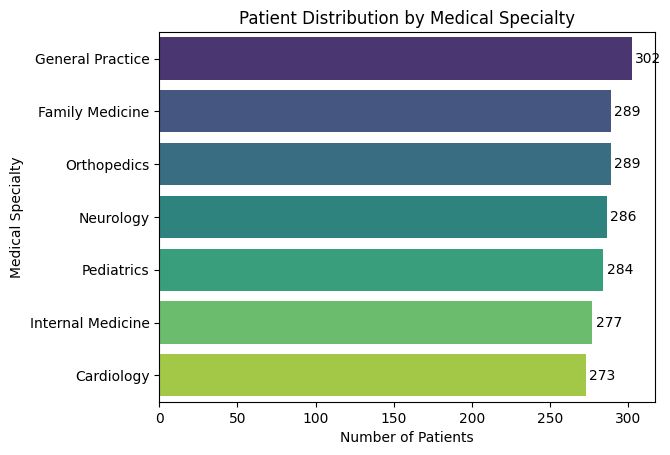

In [12]:
speciality_count = df['specialty'].value_counts().reset_index()
sns.barplot(
    x = speciality_count['count'],
    y = speciality_count['specialty'],
    palette="viridis"
)
for i in range(len(speciality_count)):
    val = speciality_count['count'].iloc[i]
    plt.text(
        x = val + 2,                    
        y = i,                            
        s = f'{val:,}',                   
        ha = 'left',                     
        va = 'center',
        fontsize = 10
    )

plt.xlabel("Number of Patients")
plt.ylabel("Medical Specialty")
plt.title("Patient Distribution by Medical Specialty")
plt.show()

In [16]:
df['visit_score'] = (
    (df['visits_last_year'] - df['visits_last_year'].min()) / 
    (df['visits_last_year'].max() - df['visits_last_year'].min())
)* 100

In [17]:
df['recency_score'] = (
    (df['days_since_last_visit'].max() - df['days_since_last_visit']) / 
    (df['days_since_last_visit'].max() - df['days_since_last_visit'].min())
) * 100

In [18]:
df['attendence_score'] = (
    (df['missed_appointments'].max() - df['missed_appointments']) / 
    (df['missed_appointments'].max() - df['missed_appointments'].min())
) * 100

In [19]:
df['tenure_score'] = (
    (df['tenure_months'] - df['tenure_months'].min()) /
    (df['tenure_months'].max() - df['tenure_months'].min())
) * 100

In [20]:
df['engagement_score'] = (
    df['visit_score'] * 0.35 + 
    df['recency_score'] * 0.35 +
    df['attendence_score'] * 0.20 + 
    df['tenure_score'] * 0.10
)

In [21]:
df['engagement_score'] = df['engagement_score'].round(2)

In [22]:
def engagement_category(score):
    if score >= 80:
        return 'Highly engaged'
    elif score >= 60:
        return 'Engaged'
    elif score >= 40:
        return 'Moderately engaged'
    elif score >= 20:
        return 'At Risk'
    else:
        return 'Disengaged'
df['engagement_category'] = df['engagement_score'].apply(engagement_category)

# Billing issue on churn

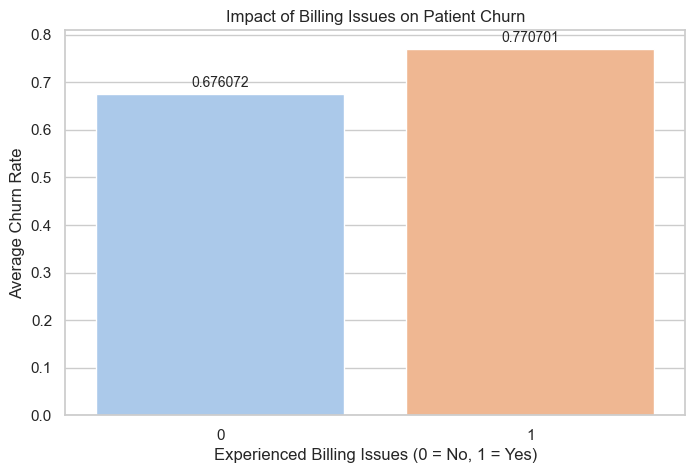

In [157]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=df, x='billing_issues', y='churned', errorbar=None, palette='pastel')
for container in ax.containers:
    ax.bar_label(container, fmt = '%f', padding = 3, fontsize = 10)
plt.title('Impact of Billing Issues on Patient Churn')
plt.xlabel('Experienced Billing Issues (0 = No, 1 = Yes)')
plt.ylabel('Average Churn Rate')
plt.show()

- patients who experienced billing issues (represented by '1') have an average churn rate of roughly 77%, compared to around 67% for those who did not experience billing issues (represented by '0').
- Fixing the billing process, improving invoice clarity, or retraining the financial department is a direct, measurable way to improve patient retention.

# Patient satisfaction

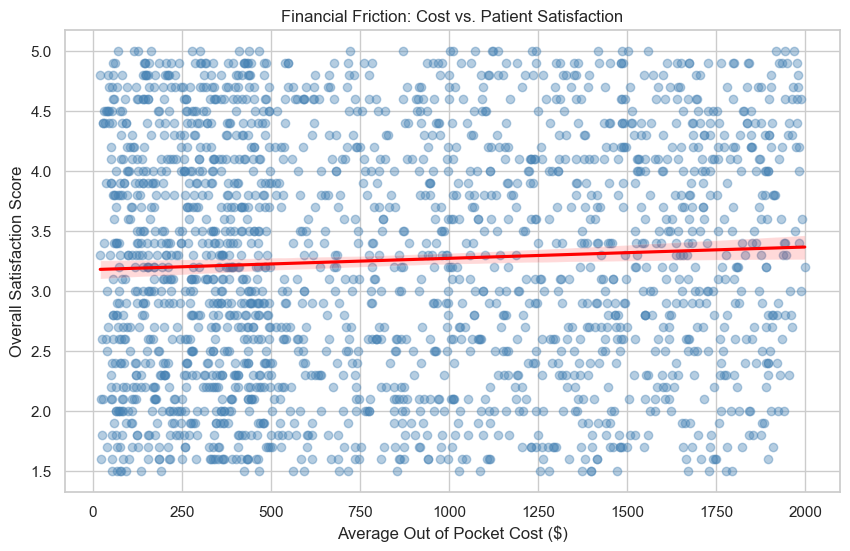

In [24]:
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df, 
    x='avg_out_of_pocket_cost', 
    y='overall_satisfaction', 
    scatter_kws={'alpha':0.4, 'color': 'steelblue'}, 
    line_kws={'color':'red'}
)
plt.title('Financial Friction: Cost vs. Patient Satisfaction')
plt.xlabel('Average Out of Pocket Cost ($)')
plt.ylabel('Overall Satisfaction Score')
plt.show()

- average out-of-pocket costs against overall satisfaction scores. The red trendline is practically flat, staying near a score of 3.2 regardless of whether the cost is 0 or 2000.
- higher out-of-pocket costs do not strongly damage overall satisfaction in this dataset. This suggests patients are evaluating their experience based on other factors (perhaps clinical quality or convenience) rather than strictly on financial burden.

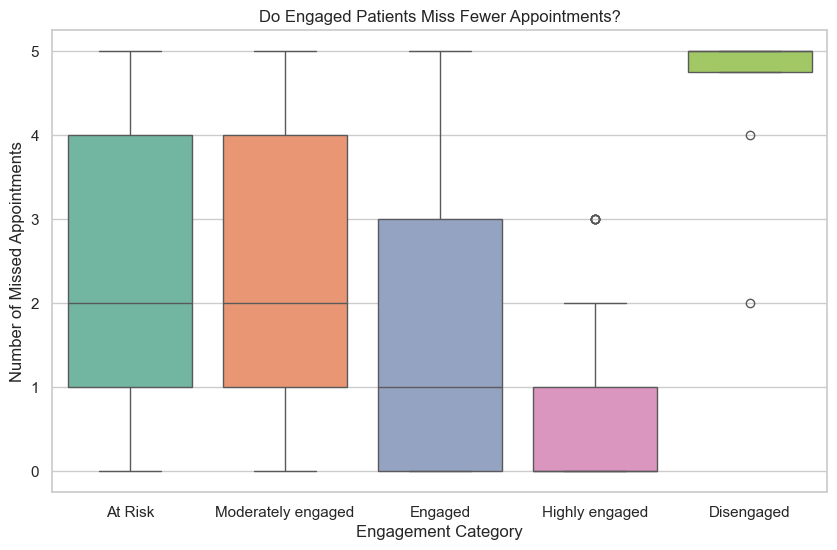

In [25]:
plt.figure(figsize = (10,6))

sns.boxplot(data = df, x = 'engagement_category', y = 'missed_appointments', palette = 'Set2')
plt.title('Do Engaged Patients Miss Fewer Appointments?')
plt.xlabel('Engagement Category')
plt.ylabel('Number of Missed Appointments')
plt.show()

- "Highly engaged" patients have the lowest median number of missed appointments (around 1) and the tightest distribution. Conversely, "Disengaged" and "At Risk" categories show higher rates of absenteeism.
- Engagement programs work. Moving a patient from "At Risk" to "Highly Engaged" directly translates to fewer no-shows, which saves the clinic money and optimizes the scheduling calendar.

# Wait Time Satisfaction by Specialty

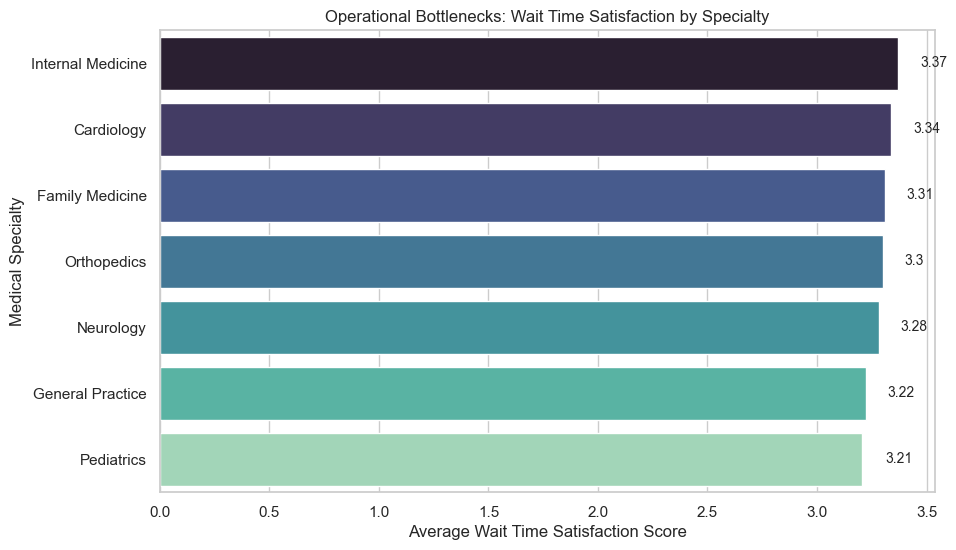

In [26]:
specialty_wait = df.groupby('specialty')['wait_time_satisfaction'].mean().sort_values(ascending=False).reset_index()
specialty_wait
plt.figure(figsize=(10, 6))
sns.barplot(data=specialty_wait, x='wait_time_satisfaction', y='specialty', palette='mako')
for i in range(len(specialty_wait)):
    val = round(specialty_wait['wait_time_satisfaction'].iloc[i],2)
    plt.text(
        x = val + 0.1,                    
        y = i,                            
        s = f'{val:,}',                   
        ha = 'left',                     
        va = 'center',
        fontsize = 10
    )
plt.title('Operational Bottlenecks: Wait Time Satisfaction by Specialty')
plt.xlabel('Average Wait Time Satisfaction Score')
plt.ylabel('Medical Specialty')
plt.show()

- There is no single "problem department" dragging down the clinic's wait-time metrics. Because the experience is uniform across the board, any initiative to improve wait times needs to be a systemic, clinic-wide operational change rather than punishing or fixing just one specific specialty.

# Churn by distance

In [27]:
df['distance_bins'] = pd.cut(
    df['distance_to_facility_miles'],
    bins = [0,5,15,30,100],
    labels = ['0-5 miles','6-15 miles','16-30 miles','30+ miles']
)

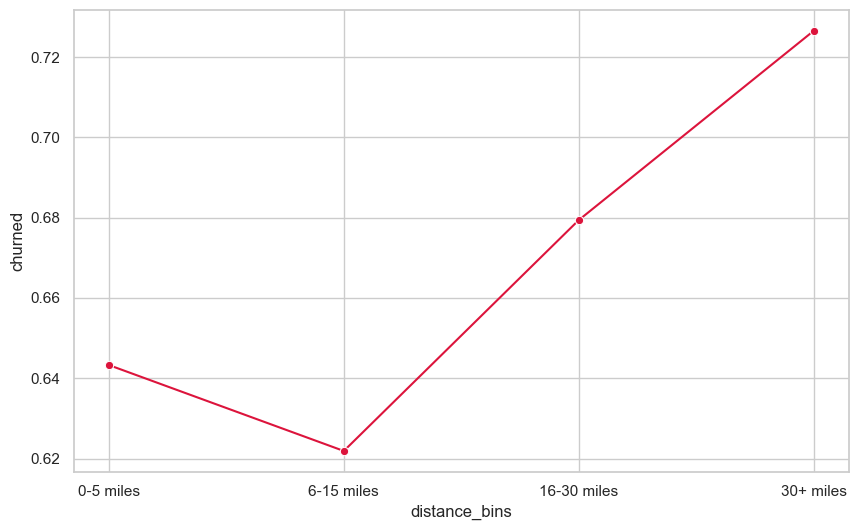

In [28]:
distance_churn = df.groupby('distance_bins')['churned'].mean().reset_index()

plt.figure(figsize = (10, 6))
sns.lineplot(
    data = distance_churn, 
    x = 'distance_bins', 
    y = 'churned', 
    marker = 'o', 
    color = 'crimson'
)
plt.show()

- while churn dips slightly for patients 6-15 miles away, it spikes dramatically for patients living 16-30 miles away, peaking at over 72% for those 30+ miles away.
- Geographic distance is a major churn risk. Once a patient is more than 15 miles away, the inconvenience outweighs their loyalty

# Portal usage in age group

In [29]:
df['age_group'] = pd.cut(
    df['age'],
    bins = [0,35,50,65,100],
    labels = ['18-35','36-50','51-65','65+']
)

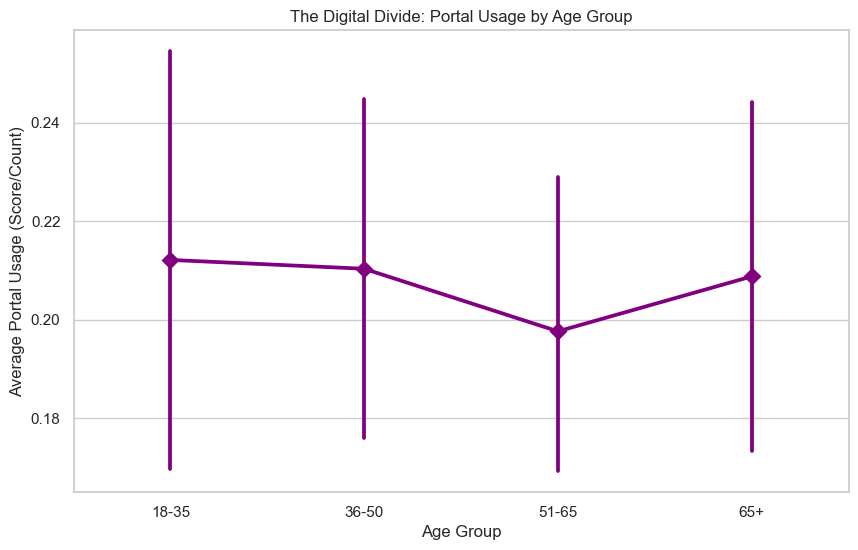

In [30]:
plt.figure(figsize = (10,6))
sns.pointplot(
    data = df,
    x = 'age_group',
    y = 'portal_usage',
    color = 'purple',
    marker = 'D'
)
plt.title('The Digital Divide: Portal Usage by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Portal Usage (Score/Count)')
plt.show()

- There is no "digital divide" limiting older patients in this clinic. The 65+ demographic is adopting digital portal tools at the same rate as millennials.
- The clinic does not need to hold back on digital-first initiatives out of fear of alienating seniors.

# Patient Satisfaction

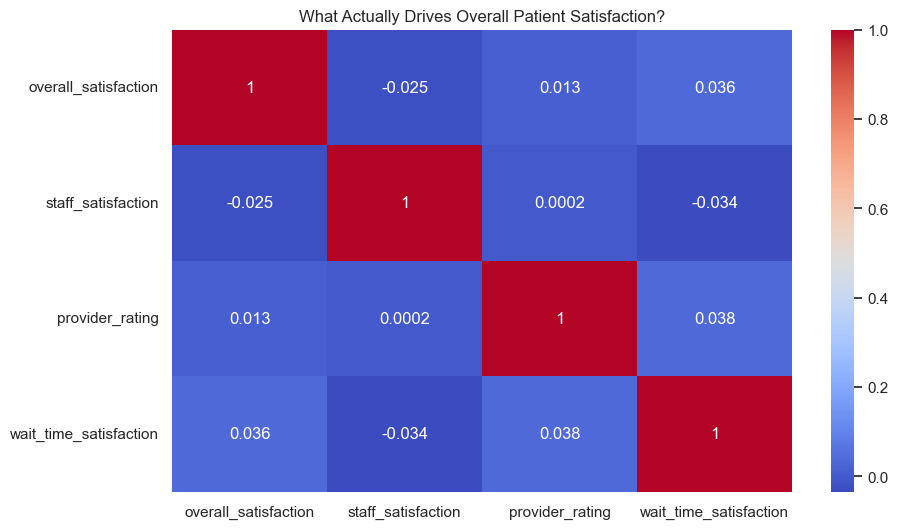

In [31]:
plt.figure(figsize = (10,6))
sat_cols = ['overall_satisfaction','staff_satisfaction','provider_rating','wait_time_satisfaction']
correlation_matrix = df[sat_cols].corr()
sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm')
plt.title('What Actually Drives Overall Patient Satisfaction?')
plt.show()

# Referrals made by patients

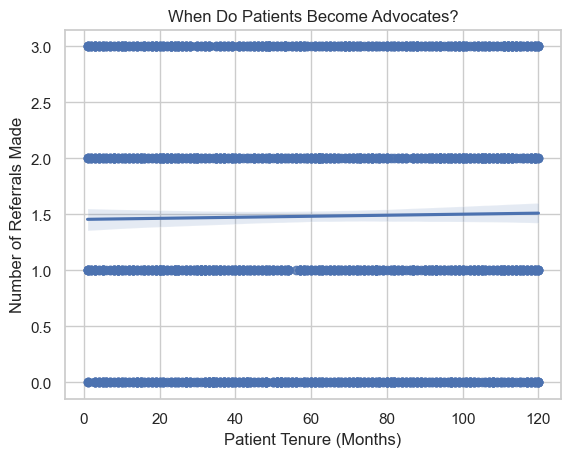

In [35]:
sns.regplot(data=df, x='tenure_months', y='referrals_made', fit_reg=True)
plt.title('When Do Patients Become Advocates?')
plt.xlabel('Patient Tenure (Months)')
plt.ylabel('Number of Referrals Made')
plt.show()

- A patient who has been with the clinic for 10 years is no more likely to refer a friend than a patient who has been there for 10 months.
- The clinic needs a structured referral incentive program rather than just hoping long-term patients will eventually spread the word.

# Patients in each state

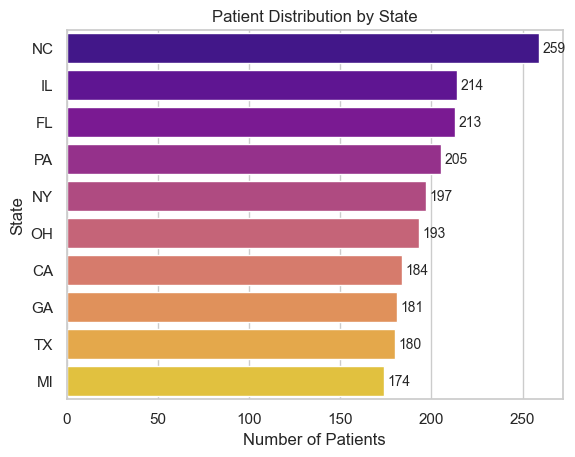

In [36]:
speciality_count = df['state'].value_counts().reset_index()
sns.barplot(
    x = speciality_count['count'],
    y = speciality_count['state'],
    palette="plasma"
)
for i in range(len(speciality_count)):
    val = speciality_count['count'].iloc[i]
    plt.text(
        x = val + 2,                    
        y = i,                            
        s = f'{val:,}',                   
        ha = 'left',                     
        va = 'center',
        fontsize = 10
    )

plt.xlabel("Number of Patients")
plt.ylabel("State")
plt.title("Patient Distribution by State")
plt.show()

- The clinic's primary market footprint is heavily anchored in North Carolina.
- Regional marketing campaigns and localized operational investments will likely yield the highest immediate volume impact in NC, IL, and FL.
- Conversely, states at the lower end of the chart represent untapped geographical growth potential.

# Missed appointments patients

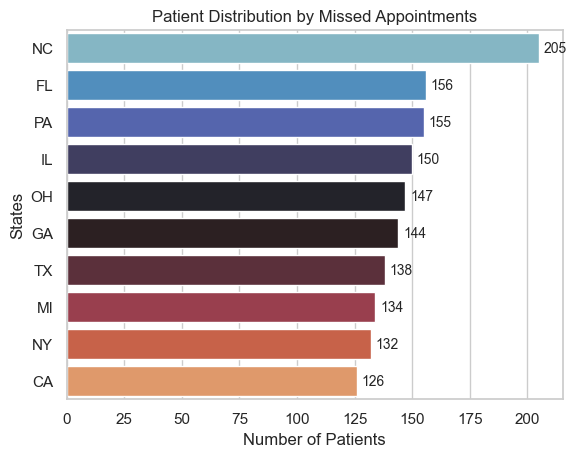

In [43]:
missed = df[df['missed_appointments'] > 0]
speciality_count = missed['state'].value_counts().reset_index()
sns.barplot(
    x = speciality_count['count'],
    y = speciality_count['state'],
    palette="icefire"
)
for i in range(len(speciality_count)):
    val = speciality_count['count'].iloc[i]
    plt.text(
        x = val + 2,                    
        y = i,                            
        s = f'{val:,}',                   
        ha = 'left',                     
        va = 'center',
        fontsize = 10
    )

plt.xlabel("Number of Patients")
plt.ylabel("States")
plt.title("Patient Distribution by Missed Appointments")
plt.show()

- The chart "Patient Distribution by missed appointments" displays the number of patients associated with missed appointments, categorized by state. North Carolina (NC) again tops the list with 205 patients.
- California (CA) has the lowest count on this chart at 126.
- This high incidence rate suggests a localized friction point in North Carolina. The business should deploy targeted intervention strategies, such as aggressive SMS reminders or investigating regional transportation/weather issues, specifically for the NC patient cohort.

# Churn by gender

In [61]:
churn_by_gender = (
    df.groupby('gender')
    .agg(
        Churn_Count = ('churned', 'sum'),
        Churn_Percentage = ('churned','mean')
    ).reset_index()
) 
churn_by_gender['Churn_Percentage'] = round(churn_by_gender['Churn_Percentage'] * 100)
churn_by_gender

,gender,Churn_Count,Churn_Percentage
0,Female,666,68.0
1,Male,701,69.0


# Patient Category

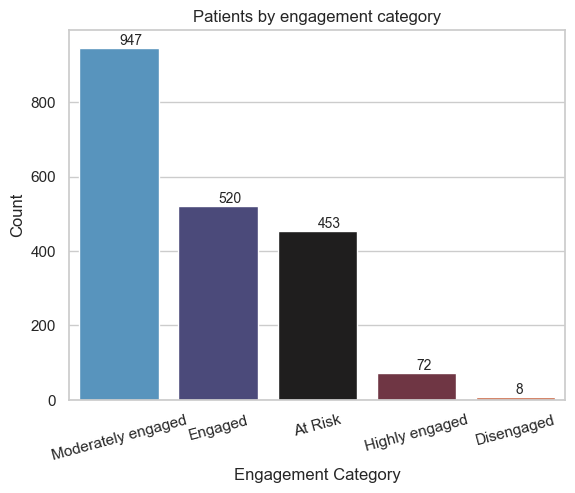

In [80]:
engagement_category = df['engagement_category'].value_counts().reset_index()

sns.barplot(
    data = engagement_category,
    x = engagement_category['engagement_category'],
    y = engagement_category['count'],
    palette = 'icefire'
)
for i in range(len(engagement_category)):
    val = engagement_category['count'].iloc[i]
    plt.text(
        y = val + 20,                    
        x = i,                            
        s = f'{val:,}',                   
        ha = 'left',                     
        va = 'center',
        fontsize = 10
    )
plt.xlabel('Engagement Category')
plt.ylabel('Count')
plt.title('Patients by engagement category')
plt.xticks(rotation=15)
plt.show()

- The vast majority of the 2,000 patients fall into the middle tiers: "Moderately engaged" (947 patients) and "Engaged" (520 patients).
- While it's excellent that very few patients are completely "Disengaged," nearly 23% of the patient base (453 patients) is sitting in the "At Risk" category.
- This "At Risk" group represents a massive vulnerability for operational efficiency and future churn.

# Insurance type in each group

In [92]:
pd.crosstab(
    df['age_group'],
    df['insurance_type']
)

insurance_type,Medicaid,Medicare,Private,Self-Pay
age_group,,,,
18-35,77,95,81,77
36-50,128,134,123,138
51-65,164,168,168,168
65+,109,119,111,140


In [96]:
insurance_by_age = df.groupby(['age_group','insurance_type'])['patientid'].count().reset_index(name = 'patient count')
insurance_by_age

,age_group,insurance_type,patient count
0,18-35,Medicaid,77
1,18-35,Medicare,95
2,18-35,Private,81
3,18-35,Self-Pay,77
4,36-50,Medicaid,128
5,36-50,Medicare,134
6,36-50,Private,123
7,36-50,Self-Pay,138
8,51-65,Medicaid,164
9,51-65,Medicare,168


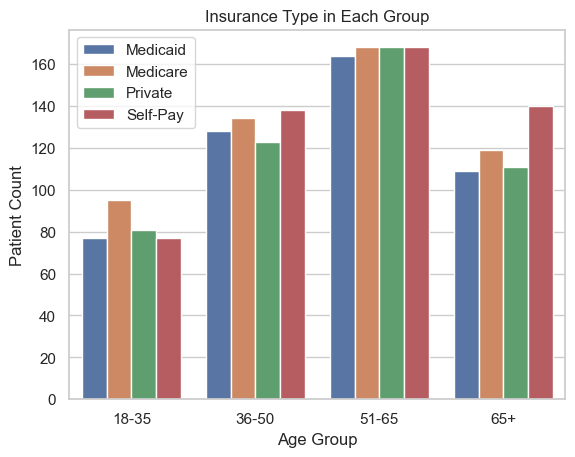

In [101]:
sns.barplot(
    data = insurance_by_age,
    x = 'age_group',
    y = 'patient count',
    hue = 'insurance_type'
)
plt.title('Insurance Type in Each Group')
plt.xlabel('Age Group')
plt.ylabel('Patient Count')
plt.legend(title = None)
plt.show()

# Billing issue in age_group

In [116]:
df[df['billing_issues'] == 1].groupby('age_group')['patientid'].count().reset_index(name = 'billing_issue_count').sort_values('billing_issue_count', ascending = False)

,age_group,billing_issue_count
2,51-65,56
1,36-50,48
0,18-35,28
3,65+,25


- Billing friction is heavily concentrated in the middle-to-late working-age demographics (36-65). This is likely because this cohort deals with the most complex insurance scenarios e.g., family plans, employer-sponsored transitions, or pre-Medicare complexities.
- The clinic's billing department should focus their process audits and customer support resources specifically on the claim types common to the 51-65 demographic to reduce administrative overhead and improve satisfaction.

# Missed appointments in age_group

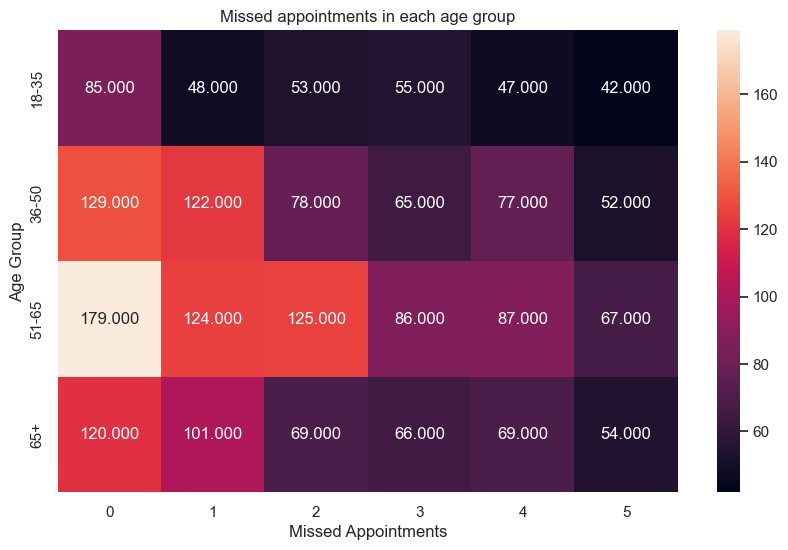

In [128]:
corr = pd.crosstab(
    df['age_group'],
    df['missed_appointments']
)
plt.figure(figsize=(10,6))
sns.heatmap(
    data = corr,
    annot = True,
    fmt = '0.3f'
)
plt.xlabel('Missed Appointments')
plt.ylabel('Age Group')
plt.title('Missed appointments in each age group')
plt.show()

# Churn in insurance type

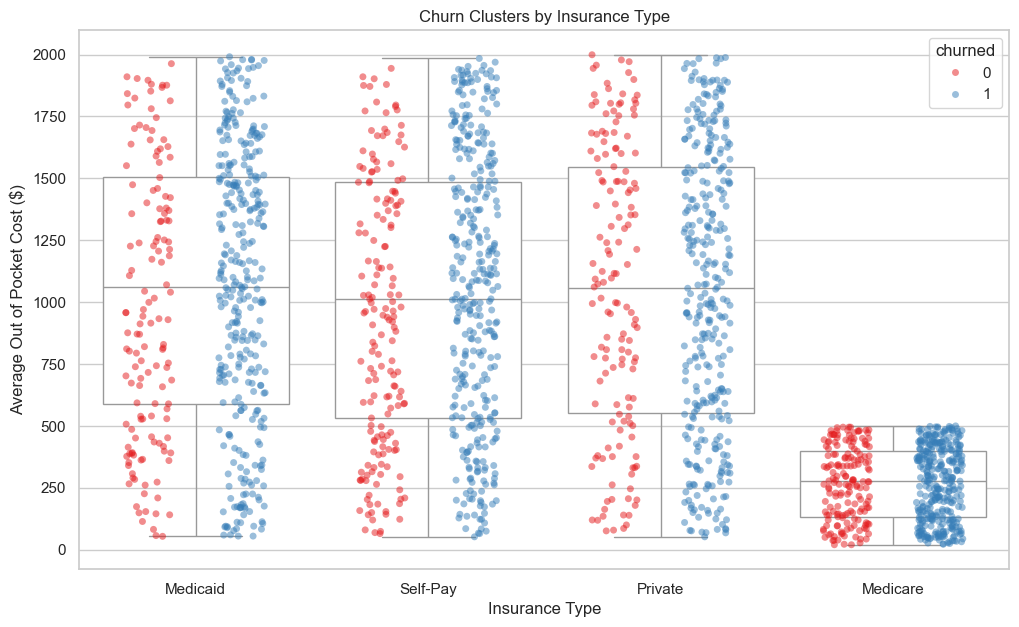

In [148]:
plt.figure(figsize=(12, 7))
sns.boxplot(
    data=df, 
    x='insurance_type', 
    y='avg_out_of_pocket_cost', 
    color='white',
    showfliers=False # Hide standard outliers to prevent overlap with stripplot
)
sns.stripplot(
    data=df, 
    x='insurance_type', 
    y='avg_out_of_pocket_cost', 
    hue='churned', 
    dodge=True, 
    alpha=0.5,
    palette='Set1',
    jitter=0.2
)
plt.title('Churn Clusters by Insurance Type')
plt.xlabel('Insurance Type')
plt.ylabel('Average Out of Pocket Cost ($)')
plt.show()

- breaks down the average out-of-pocket cost by insurance type, coloring individual patients by whether they stayed (red = 0) or churned (blue = 1). Medicaid, Self-Pay, and Private insurance exhibit an identical, wide-ranging cost distribution

# Churn Rate

In [146]:
churn_rate = df['churned'].mean() * 100
print(f"Overall Patient Churn Rate: {churn_rate:.2f}%")

Overall Patient Churn Rate: 68.35%


In [150]:
df.to_csv('updated healthcare.csv', index = False)
print('File Saved Successfully')

File Saved Successfully
